In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
test_df=pd.read_csv("../Notebook/Data/customer_churn_dataset-testing-master.csv")

In [3]:
train_df=pd.read_csv("../Notebook/Data/customer_churn_dataset-training-master.csv")

In [4]:
#concat datasets
df=pd.concat([train_df,test_df],axis=0).reset_index(drop=True)

In [5]:
df

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
505202,64370.0,45.0,Female,33.0,12.0,6.0,21.0,Basic,Quarterly,947.0,14.0,1.0
505203,64371.0,37.0,Male,6.0,1.0,5.0,22.0,Standard,Annual,923.0,9.0,1.0
505204,64372.0,25.0,Male,39.0,14.0,8.0,30.0,Premium,Monthly,327.0,20.0,1.0
505205,64373.0,50.0,Female,18.0,19.0,7.0,22.0,Standard,Monthly,540.0,13.0,1.0


Basic Dataset Exploration

In [6]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [7]:
df.shape

(505207, 12)

In [8]:
df.isnull().sum()

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [9]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000
mean,200779.451782,39.704172,31.350435,15.714825,3.833317,13.496843,620.072766,14.610581,0.555203
std,137241.343095,12.670577,17.237482,8.619323,3.133603,8.451187,245.319256,8.608286,0.496944
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,63827.250000,29.000000,16.000000,8.000000,1.000000,6.000000,446.000000,7.000000,0.000000
50%,193039.500000,40.000000,32.000000,16.000000,3.000000,13.000000,648.900000,14.000000,1.000000
75%,321645.750000,49.000000,46.000000,23.000000,6.000000,20.000000,824.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [10]:
#drop missing values
df.dropna(inplace=True)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.columns.to_list()

['CustomerID',
 'Age',
 'Gender',
 'Tenure',
 'Usage Frequency',
 'Support Calls',
 'Payment Delay',
 'Subscription Type',
 'Contract Length',
 'Total Spend',
 'Last Interaction',
 'Churn']

Here drop CustomerID columns ,it does not help in analysis much

In [13]:
df.drop(columns=["CustomerID"],inplace=True)

In [14]:
categorical_cols,Numerical_cols=[col for col in df.columns if df[col].dtype=="str"],[col for col in df.columns if df[col].dtype!="str"]

In [15]:
for col in df.columns:
    print(f"{col} : {df[col].nunique()} unique values")

Age : 48 unique values
Gender : 2 unique values
Tenure : 60 unique values
Usage Frequency : 30 unique values
Support Calls : 11 unique values
Payment Delay : 31 unique values
Subscription Type : 3 unique values
Contract Length : 3 unique values
Total Spend : 68363 unique values
Last Interaction : 30 unique values
Churn : 2 unique values


In [16]:
Numerical_cols,categorical_cols

(['Age',
  'Tenure',
  'Usage Frequency',
  'Support Calls',
  'Payment Delay',
  'Total Spend',
  'Last Interaction',
  'Churn'],
 ['Gender', 'Subscription Type', 'Contract Length'])

EDA-->Univariate Analysis

In [17]:
for col in categorical_cols:
    print(f"{col} : {df[col].unique()}")
    print("-"*30)

Gender : <StringArray>
['Female', 'Male']
Length: 2, dtype: str
------------------------------
Subscription Type : <StringArray>
['Standard', 'Basic', 'Premium']
Length: 3, dtype: str
------------------------------
Contract Length : <StringArray>
['Annual', 'Monthly', 'Quarterly']
Length: 3, dtype: str
------------------------------


Report:

1. Subscription has 3 category ['Standard', 'Basic', 'Premium']

2. Subscription Package has also 3 category ['Annual', 'Monthly', 'Quarterly']

Gender : Gender
Male      55.476974
Female    44.523026
Name: proportion, dtype: float64
------------------------------


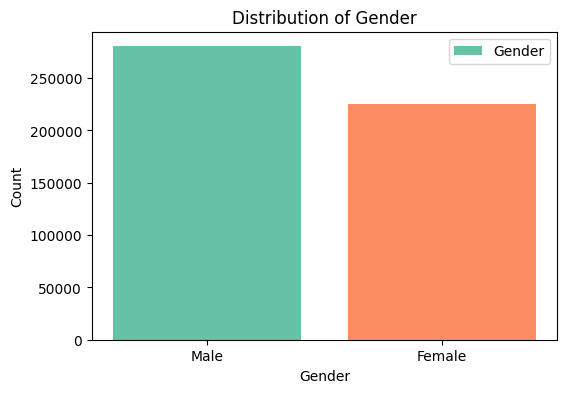

Subscription Type : Subscription Type
Standard    33.774342
Premium     33.669236
Basic       32.556423
Name: proportion, dtype: float64
------------------------------


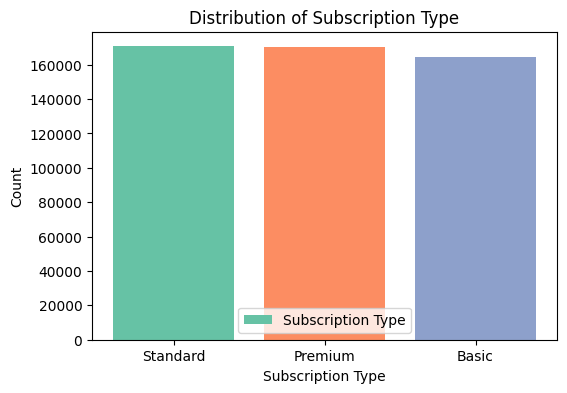

Contract Length : Contract Length
Annual       39.312281
Quarterly    39.066044
Monthly      21.621675
Name: proportion, dtype: float64
------------------------------


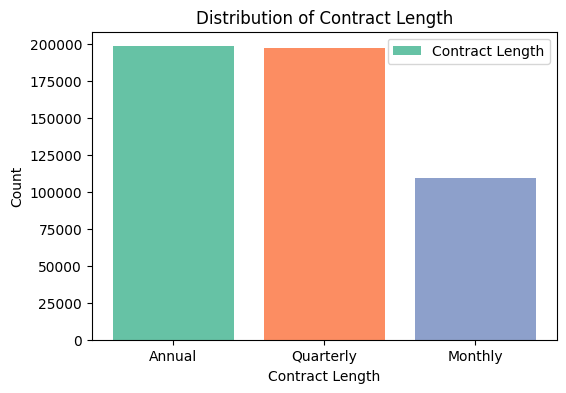

Contract Length : Churn
1.0    55.520322
0.0    44.479678
Name: proportion, dtype: float64
------------------------------


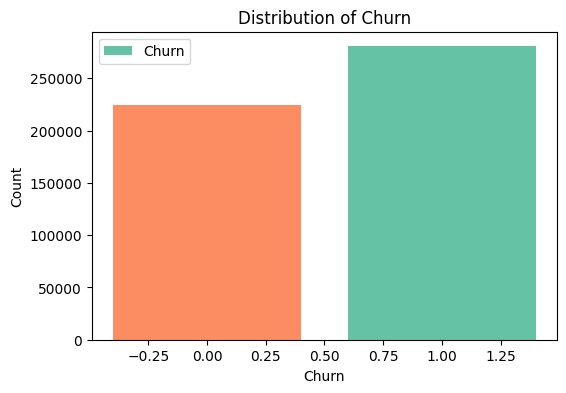

In [18]:
for col in categorical_cols:
    print(f"{col} : {df[col].value_counts(normalize=True)*100}")
    print("-"*30)
    plt.figure(figsize=(6,4))
    plt.bar(df[col].value_counts().index,df[col].value_counts().values,label=col,color=sns.color_palette("Set2"))
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.title(f"Distribution of {col}")
    plt.legend()
    plt.show()
#also plot churn count ,treat it as a categorical variable

print(f"{col} : {df["Churn"].value_counts(normalize=True)*100}")
print("-"*30)
plt.figure(figsize=(6,4))
plt.bar(df["Churn"].value_counts().index,df["Churn"].value_counts().values,label="Churn",color=sns.color_palette("Set2"))
plt.xlabel("Churn")
plt.ylabel("Count")
plt.title(f"Distribution of Churn")
plt.legend()
plt.show()

Report:

1.) Males are more in number 

2.)In subscription Type people's taken all plan equally not having any bias

3.)Annual and Quarterly are dominating the Contract length

4.) Most people has churned from site

In [19]:
discrete_cols=[col for col in Numerical_cols if df[col].nunique()<10]    
continuous_cols=[col for col in Numerical_cols if col not in discrete_cols]

Distribution of Age columns and Total Spend columns

<Axes: ylabel='Frequency'>

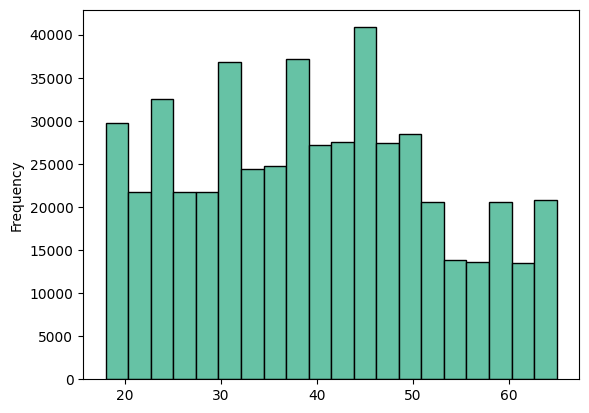

In [20]:
df['Age'].plot.hist(bins=20,color=sns.color_palette("Set2"),edgecolor='black')

<Axes: ylabel='Frequency'>

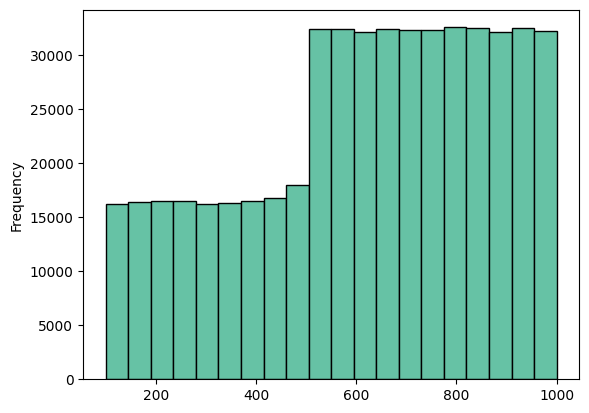

In [21]:
df['Total Spend'].plot.hist(bins=20,color=sns.color_palette("Set2"),edgecolor='black')

Report:

1.) Most people are of age group of 20-50

2.)most People spends money  between 600-100

EDA--->Bivaraiate Analysis

In [22]:
df.columns

Index(['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend',
       'Last Interaction', 'Churn'],
      dtype='str')

By Age Group ,how much of money people spending on..?

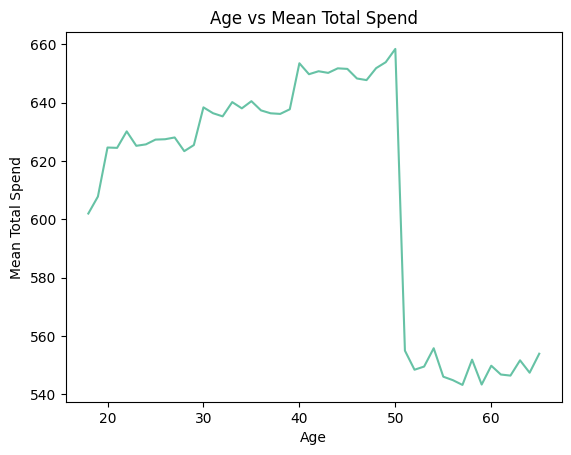

In [23]:
df.groupby("Age")['Total Spend'].mean().plot.line(color=sns.color_palette("Set2"))
plt.xlabel("Age")
plt.ylabel("Mean Total Spend")
plt.title("Age vs Mean Total Spend")
plt.show()

Report :

People of Age group 20-50 are spend more money rather than of age group 50+

By age group ,which people are more likely to churn

<Axes: ylabel='Frequency'>

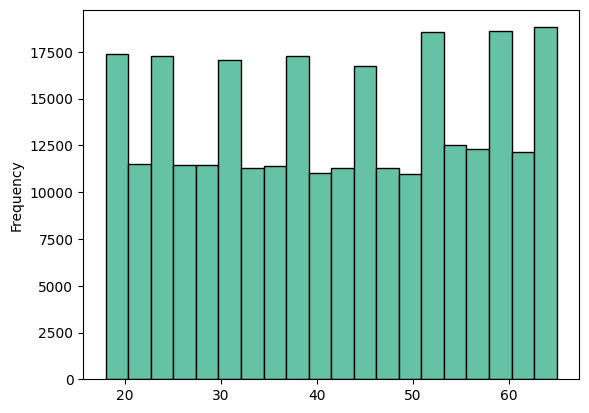

In [24]:
df[df['Churn']==1]['Age'].plot.hist(bins=20,color=sns.color_palette("Set2"),edgecolor='black')

In [25]:
df[df['Age']>50]['Churn'].value_counts(normalize=True)*100  

Churn
1.0    90.239972
0.0     9.760028
Name: proportion, dtype: float64

Report:

Age group of 50+ are having very high churn rate 90%

In [26]:
df.columns

Index(['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend',
       'Last Interaction', 'Churn'],
      dtype='str')

People who churned ,what was their subscription type

In [27]:
df[df['Churn']==1]['Subscription Type'].value_counts(normalize=True)*100

Subscription Type
Standard    33.438743
Basic       33.357814
Premium     33.203443
Name: proportion, dtype: float64

Report:

There is no pattern in this or cause to leave 

In [28]:
df.columns

Index(['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend',
       'Last Interaction', 'Churn'],
      dtype='str')

By gender,whom was likely to churn 

<Axes: xlabel='Gender'>

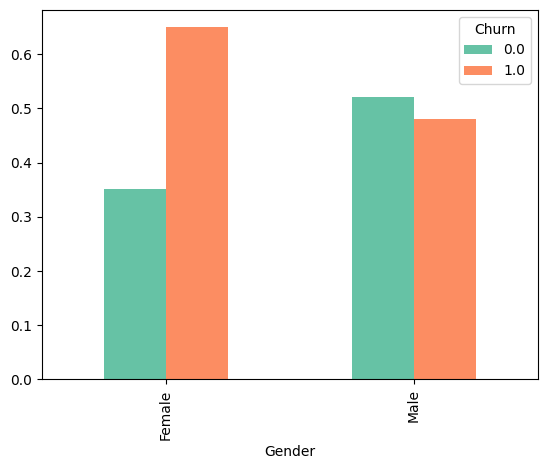

In [29]:
df.groupby('Gender')['Churn'].value_counts(normalize=True).unstack().plot.bar(color=sns.color_palette("Set2"))  

So,what was the age of female who was churning more

In [30]:
temp=df[df['Gender']=='Female'][['Age','Churn']]

In [31]:
temp[temp['Churn']==1]['Age'].mean()


np.float64(41.72181079544287)

In [32]:
(temp[temp['Churn']==1]['Age'].value_counts().sum()/280492)*100

np.float64(52.04034339660312)

In [33]:
temp[temp['Churn']==1][temp["Age"]>50].value_counts().sum()/280492*100


np.float64(16.888182194144573)

Report:

Female client was churning more than male 

Female client whose mean age is 41,42 are churn more

From all churned people ,Female client has 52% of contrubution in it

And about 17% female of age group 50+ are churned

In [34]:
df['Churn'].value_counts() # Total churn count

Churn
1.0    280492
0.0    224714
Name: count, dtype: int64

In [35]:
df.columns

Index(['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend',
       'Last Interaction', 'Churn'],
      dtype='str')

Total Spend by Gender

In [36]:
df.groupby("Gender")['Total Spend'].mean()

Gender
Female    601.225031
Male      635.199009
Name: Total Spend, dtype: float64

Report :

Females spends 600 rs on an average and Men spends 635rs on an average

what is Average Age of men and Women

In [42]:
df.groupby("Gender")['Age'].mean()

Gender
Female    40.145875
Male      39.349684
Name: Age, dtype: float64

Frequency usage on basis of Age

In [51]:
df.groupby("Usage Frequency")['Age'].mean()

Usage Frequency
1.0     40.200951
2.0     40.108509
3.0     40.192150
4.0     40.191725
5.0     40.107643
6.0     39.925844
7.0     39.815057
8.0     39.912966
9.0     39.866300
10.0    39.405086
11.0    39.810893
12.0    39.497486
13.0    39.607537
14.0    39.535598
15.0    39.538219
16.0    39.503668
17.0    39.639283
18.0    39.567246
19.0    39.464451
20.0    39.480042
21.0    39.661672
22.0    39.559364
23.0    39.617486
24.0    39.571437
25.0    39.459314
26.0    39.672183
27.0    39.658616
28.0    39.634471
29.0    39.665823
30.0    39.441946
Name: Age, dtype: float64

Usage Frequency of a customer who has churned 

In [64]:
df[df['Churn']==1]['Usage Frequency'].value_counts().sort_values(ascending=False).head(5)/df[df['Churn']==1]['Usage Frequency'].value_counts().sum()*100

Usage Frequency
1.0    3.683171
2.0    3.671762
3.0    3.540921
5.0    3.508121
4.0    3.497426
Name: count, dtype: float64

Report :

Of Total churn ,18% are those who has monthly usage is 1-5

what is duration of subcription type those are taking

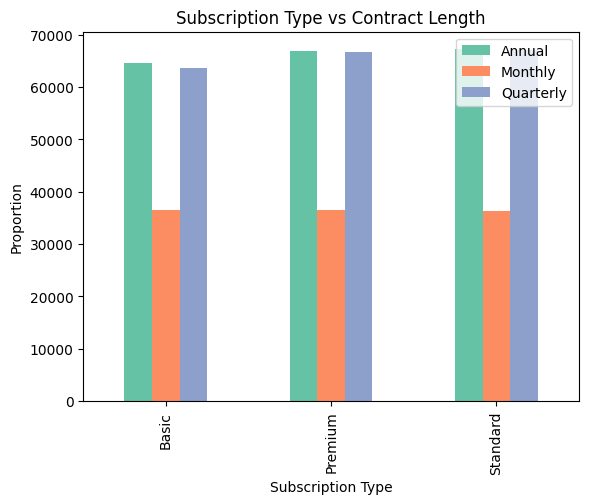

In [73]:
df.groupby('Subscription Type')['Contract Length'].value_counts().unstack().plot.bar(color=sns.color_palette("Set2"))
plt.xlabel("Subscription Type")
plt.ylabel("Proportion")
plt.title("Subscription Type vs Contract Length")
plt.legend()    

Report :

Monthly plan was less of all type was takes less

Annual and Quarterly of Basics and Premium was taken more

Multivaraite Analysis

In [66]:
df.columns

Index(['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend',
       'Last Interaction', 'Churn'],
      dtype='str')

What was the last interaction who churned or what is their subscription type

In [86]:
temp=df[df['Churn']==1][['Last Interaction','Subscription Type']]

In [98]:
temp.groupby('Subscription Type')['Last Interaction'].value_counts(normalize=True)*100

Subscription Type  Last Interaction
Basic              19.0                3.449971
                   23.0                3.448902
                   16.0                3.436077
                   25.0                3.415771
                   7.0                 3.402946
                                         ...   
Standard           15.0                3.265702
                   11.0                3.262504
                   14.0                3.233717
                   4.0                 3.225187
                   8.0                 3.197467
Name: proportion, Length: 90, dtype: float64

Report :
 
 Basic and Standard Plan has churned with last interaction is 15 days on an average 

In [101]:
#plot heatmap
df_copy=df.copy()

In [109]:
def map_str(df):
    for col in df.columns:
        if df[col].dtype=="str":
                #map it to a number
                df[col] = df[col].map({unique_value: i for i, unique_value in enumerate(df[col].unique())})

In [110]:
map_str(df_copy)

In [111]:
df_copy

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,30.0,0,39.0,14.0,5.0,18.0,0,0,932.0,17.0,1.0
1,65.0,0,49.0,1.0,10.0,8.0,1,1,557.0,6.0,1.0
2,55.0,0,14.0,4.0,6.0,18.0,1,2,185.0,3.0,1.0
3,58.0,1,38.0,21.0,7.0,7.0,0,1,396.0,29.0,1.0
4,23.0,1,32.0,20.0,5.0,8.0,1,1,617.0,20.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
505202,45.0,0,33.0,12.0,6.0,21.0,1,2,947.0,14.0,1.0
505203,37.0,1,6.0,1.0,5.0,22.0,0,0,923.0,9.0,1.0
505204,25.0,1,39.0,14.0,8.0,30.0,2,1,327.0,20.0,1.0
505205,50.0,0,18.0,19.0,7.0,22.0,0,1,540.0,13.0,1.0


<Axes: >

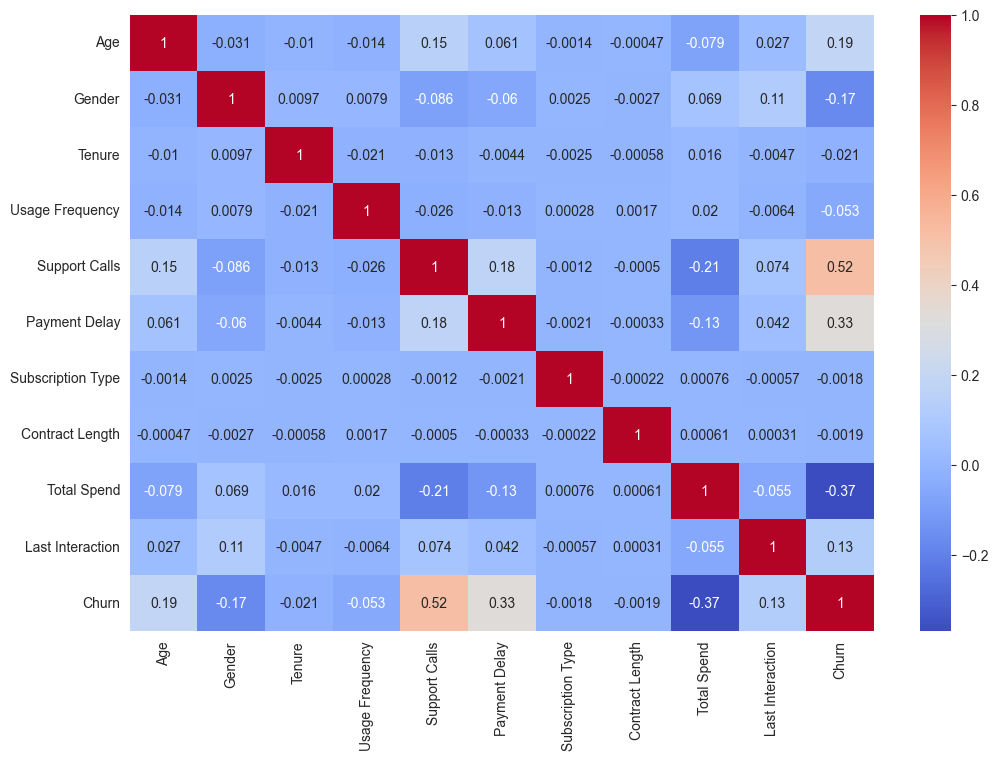

In [113]:
plt.figure(figsize=(12,8)   )
sns.heatmap(df_copy.corr(),annot=True,cmap="coolwarm")

Report :

Support Calls,Payment delay has highly corrrelated

Age and Last interaction has also positive correlation

In [114]:
df.columns

Index(['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend',
       'Last Interaction', 'Churn'],
      dtype='str')

Feature Engineering

In [115]:
df

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
505202,45.0,Female,33.0,12.0,6.0,21.0,Basic,Quarterly,947.0,14.0,1.0
505203,37.0,Male,6.0,1.0,5.0,22.0,Standard,Annual,923.0,9.0,1.0
505204,25.0,Male,39.0,14.0,8.0,30.0,Premium,Monthly,327.0,20.0,1.0
505205,50.0,Female,18.0,19.0,7.0,22.0,Standard,Monthly,540.0,13.0,1.0


In [ ]:
#lets make columns of total time spent on basis of usage frequency and  tenure and contract length

In [118]:
df2_copy=df.copy()

In [122]:
df2_copy['Contract Length']=df2_copy['Contract Length'].map({'Annual':12,'Monthly':1,'Quarterly':6})

In [124]:
df2_copy['Gender']=df2_copy['Gender'].map({"Female":0,"Male":1})
df2_copy['Subscription Type']=df2_copy['Subscription Type'].map({"Basic":0,"Standard":1,"Premium":2})

In [130]:
df2_copy['Total_Usage_Frequency'] = df2_copy["Contract Length"]*df2_copy["Usage Frequency"]*df2_copy["Tenure"]

In [132]:
#drop columns which are not needed
df2_copy.drop(columns=["Contract Length","Usage Frequency","Tenure","Total_Time_Spent"],inplace=True)

In [134]:
df2_copy.corr()

,Age,Gender,Support Calls,Payment Delay,Subscription Type,Total Spend,Last Interaction,Churn,Total_Usage_Frequency
Age,1.000000,-0.031230,0.146790,0.060569,-0.004396,-0.078679,0.027472,0.191224,-0.041410
Gender,-0.031230,1.000000,-0.086223,-0.060205,0.002785,0.068828,0.114329,-0.168989,0.036564
Support Calls,0.146790,-0.086223,1.000000,0.176038,-0.010185,-0.206566,0.074070,0.516283,-0.097685
Payment Delay,0.060569,-0.060205,0.176038,1.000000,-0.006047,-0.125975,0.041767,0.329785,-0.056728
Subscription Type,-0.004396,0.002785,-0.010185,-0.006047,1.000000,0.007343,-0.001463,-0.017399,-0.010144
Total Spend,-0.078679,0.068828,-0.206566,-0.125975,0.007343,1.000000,-0.054560,-0.369682,0.073955
Last Interaction,0.027472,0.114329,0.074070,0.041767,-0.001463,-0.054560,1.000000,0.127150,-0.025937
Churn,0.191224,-0.168989,0.516283,0.329785,-0.017399,-0.369682,0.127150,1.000000,-0.176777
Total_Usage_Frequency,-0.041410,0.036564,-0.097685,-0.056728,-0.010144,0.073955,-0.025937,-0.176777,1.000000


Using VIF to check Multocollineraity

In [137]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
def check_VIF(df):
    vif_data = pd.DataFrame()
    vif_data["feature"] = df.columns
    vif_data["VIF"] = [variance_inflation_factor(df.values, i) for i in range(len(df.columns))]
    return vif_data


In [ ]:
check_VIF(df2_copy.drop(columns=["Churn"]))

,feature,VIF
0,Age,7.445647
1,Gender,2.236804
2,Support Calls,2.628148
3,Payment Delay,3.380653
4,Subscription Type,2.405111
5,Total Spend,5.316269
6,Last Interaction,3.659528
7,Total_Usage_Frequency,1.763220


Age is Highly correlated, bt not consider it for droppinng now

In [141]:
#check for outlier in Data
discrete_col=[col for col in df2_copy.columns if df2_copy[col].nunique()<30 and col!="Churn"]
continuous_cols=[col for col in df2_copy.columns if col not in discrete_col and col!="Churn"]

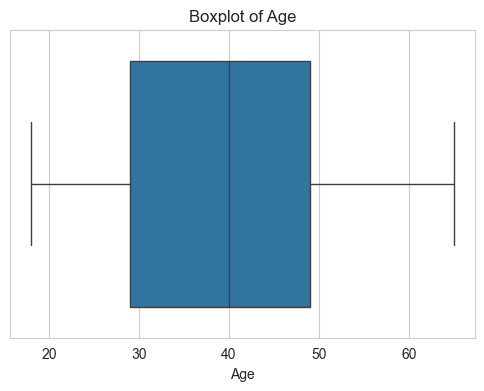

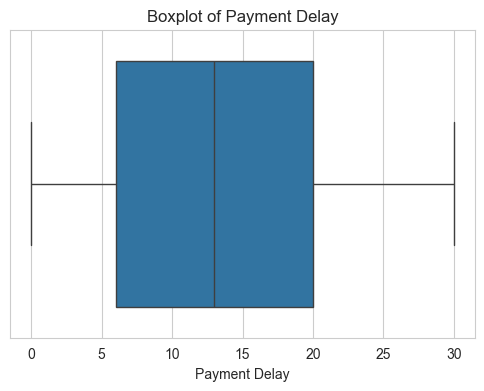

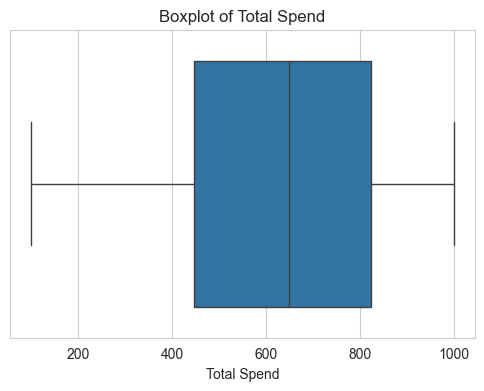

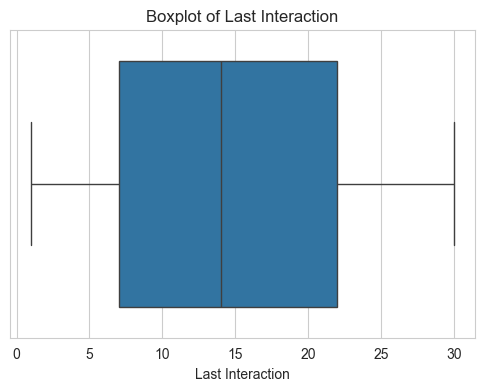

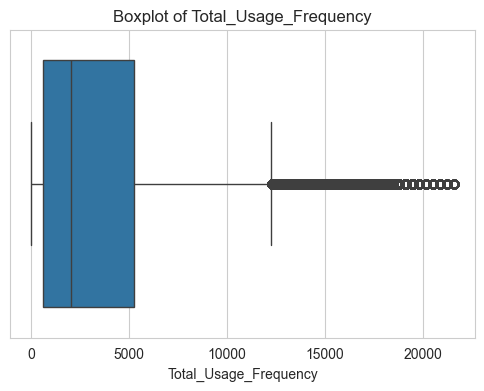

In [ ]:
for col in continuous_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df2_copy[col])
    plt.title(f"Boxplot of {col}")
    plt.show()
    

Report :

Total Usage Frequency has an outlier 

Final Report :

1. Correlation Analysis:

Age shows a strong correlation with churn, but it is not dropped at this stage since it may still carry predictive value.

Support Calls and Payment Delay are highly correlated, indicating possible redundancy.

Age and Last Interaction also show a positive correlation, suggesting older users may interact differently before churning.

2. Customer Behavior Insights:

Customers with Basic and Standard plans tend to churn when their last interaction is ~15 days ago (on average).

Low monthly usage (1–5) contributes to about 18% of total churn, indicating low engagement is a risk factor.

Most churned customers show signs of reduced activity before leaving

3. Subscription & Plan Trends:

Subscription types: Basic, Standard, Premium

Contract types: Annual, Monthly, Quarterly

Key observations:

Monthly plans are least preferred overall

Annual and Quarterly plans dominate, especially for Basic and Premium users

Plan selection is fairly balanced across subscription types (no strong bias)

A large portion of churned users comes from the platform/site channel

4. Spending Patterns

Average spending:

Females: ~₹600

Males: ~₹635

Age group 20–50 spends more compared to 50+ group

Most users spend in the range of ₹600–₹1000

5. Gender-Based Insights:

Female customers churn more than male customers

Contribution to total churn:
Females: ~52%

High-risk segment:

Female customers aged 41–42 show higher churn

About 17% of churned females are aged 50+

. Age-Based Insights:

Age group 50+ has extremely high churn (~90%), making it the most critical risk group

Majority of customers belong to the 20–50 age group

However, this group is more valuable (higher spending) and relatively more stable

7. Customer Distribution

Males are slightly higher in number overall

Majority of customers fall in:

Age: 20–50

Spending: ₹600–₹1000

8. Key Risk Indicators of Churn

Customers are more likely to churn if they:

Have low usage (1–5 per month)

Show no interaction for ~15 days

Belong to age group 50+

Are female (especially mid-age or older segments)

Experience payment delays or frequent support issues